# ERA5 multi-winter blocking benchmark

This notebook is the next step after the two-window TM1990 demonstration. It
uses the same detector over five complete December–February winters:
2020–21 through 2024–25. The purpose is **not** to claim a final blocking
climatology. The purpose is to test whether the diagnostic produces a
stable, interpretable longitude pattern before we use it to evaluate EERIE.

The notebook answers four practical questions:

1. Did we download complete, regular 6-hourly 500 hPa fields?
2. How often does the raw gradient rule identify a candidate?
3. How much does the 20° sector filter reduce those candidates?
4. Does the pooled longitude pattern look physically interpretable, or does
   the implementation need correction before we continue?

Only Z500 is downloaded for this benchmark. Wind and surface pressure are not
needed for TM1990, so the Z500-only cache avoids repeating the much larger
wind download. The results are still a pilot benchmark: five winters are
useful for validation, but not enough for a publication-quality climatology.


In [1]:
# Set up the five-winter benchmark and load the Z500-only ERA5 loader.
# ruff: noqa: E402
import sys
from datetime import datetime
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
import yaml
from IPython.display import display

from eurogrid.data.era5 import load_era5_z500
from eurogrid.diagnostics.blocking import detect_tm1990, persistence_summary

with open(ROOT / "config/settings.yaml") as handle:
    cfg = yaml.safe_load(handle)

blocking_cfg = cfg["blocking"]
benchmark_windows = blocking_cfg["benchmark_windows"]

In [2]:
# Load or create the five local Z500 caches and verify their dimensions.
z500_by_winter = {}
inventory_rows = []
for window in benchmark_windows:
    z500 = load_era5_z500(
        datetime.fromisoformat(window["start"]),
        datetime.fromisoformat(window["end"]),
        **blocking_cfg["domain"],
        cache_dir=ROOT / cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
    z500_by_winter[window["label"]] = z500
    inventory_rows.append(
        {
            "winter": window["label"],
            "timesteps": z500.sizes["time_z500"],
            "latitudes": z500.sizes["lat"],
            "longitudes": z500.sizes["lon"],
            "lat_range": f"{float(z500.lat.max()):g} to {float(z500.lat.min()):g}°N",
            "lon_range": f"{float(z500.lon.min()):g} to {float(z500.lon.max()):g}°E",
            "first_utc": str(z500.time_z500.values[0])[:16],
            "last_utc": str(z500.time_z500.values[-1])[:16],
        }
    )
inventory = pl.DataFrame(inventory_rows)
display(inventory)

winter,timesteps,latitudes,longitudes,lat_range,lon_range,first_utc,last_utc
str,i64,i64,i64,str,str,str,str
"""2020-21""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2020-12-01T00:00""","""2021-02-28T18:00"""
"""2021-22""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2021-12-01T00:00""","""2022-02-28T18:00"""
"""2022-23""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2022-12-01T00:00""","""2023-02-28T18:00"""
"""2023-24""",364,221,321,"""85 to 30°N""","""-40 to 40°E""","""2023-12-01T00:00""","""2024-02-29T18:00"""
"""2024-25""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2024-12-01T00:00""","""2025-02-28T18:00"""


**Table — benchmark data inventory.** Every row should contain a complete
December–February window, 6-hourly timestamps, the expanded 30–85°N domain,
and the same longitude grid. This is a data-completeness check before any
frequency is interpreted. The cache contains only `z500`, because TM1990
uses geopotential height rather than wind or generation.


In [3]:
# Apply the same TM1990 detector and persistence rule to every winter.
results = {}
persistence = {}
summary_rows = []
for label, z500 in z500_by_winter.items():
    result = detect_tm1990(
        z500,
        phi0_deg=blocking_cfg["phi0_deg"],
        arm_deg=blocking_cfg["arm_deg"],
        scan_offsets_deg=tuple(blocking_cfg["scan_offsets_deg"]),
        ghgn_threshold_m_per_deg=blocking_cfg["ghgn_threshold_m_per_deg"],
        min_sector_width_deg=blocking_cfg["min_sector_width_deg"],
    )
    summary_result = persistence_summary(
        result.blocking,
        timestep_hours=cfg["era5"]["z500_stride_hours"],
        min_persistence_days=blocking_cfg["min_persistence_days"],
    )
    results[label] = result
    persistence[label] = summary_result
    summary_rows.append(
        {
            "winter": label,
            "candidate_fraction": float(result.candidate.mean()),
            "sector_qualified_fraction": float(result.blocking.mean()),
            "persistent_fraction": float(summary_result.persistent_blocking.mean()),
            "mean_blocked_longitudes": float(summary_result.blocking_longitude_count.mean()),
            "maximum_blocked_longitudes": int(summary_result.blocking_longitude_count.max()),
        }
    )
summary = pl.DataFrame(summary_rows)
display(summary)

winter,candidate_fraction,sector_qualified_fraction,persistent_fraction,mean_blocked_longitudes,maximum_blocked_longitudes
str,f64,f64,f64,f64,i64
"""2020-21""",0.094592,0.051263,0.0,16.455556,275
"""2021-22""",0.117688,0.085999,0.0,27.605556,277
"""2022-23""",0.168847,0.140957,0.213889,45.247222,244
"""2023-24""",0.072832,0.048826,0.07967,15.673077,275
"""2024-25""",0.15681,0.108766,0.138889,34.913889,259


**Table — one row per winter.** `candidate_fraction` is the proportion of
time–longitude cells passing only the two gradient rules. The
`sector_qualified_fraction` additionally requires a continuous 20° longitude
sector. `persistent_fraction` counts timestamps inside a five-day,
domain-wide run. `mean_blocked_longitudes` is the average number of blocked
longitude grid cells at a timestamp; it is not an area and not an event count.
The maximum is a useful sanity check for unusually broad detections. We are
looking for a plausible and stable pattern, not selecting a preferred winter.


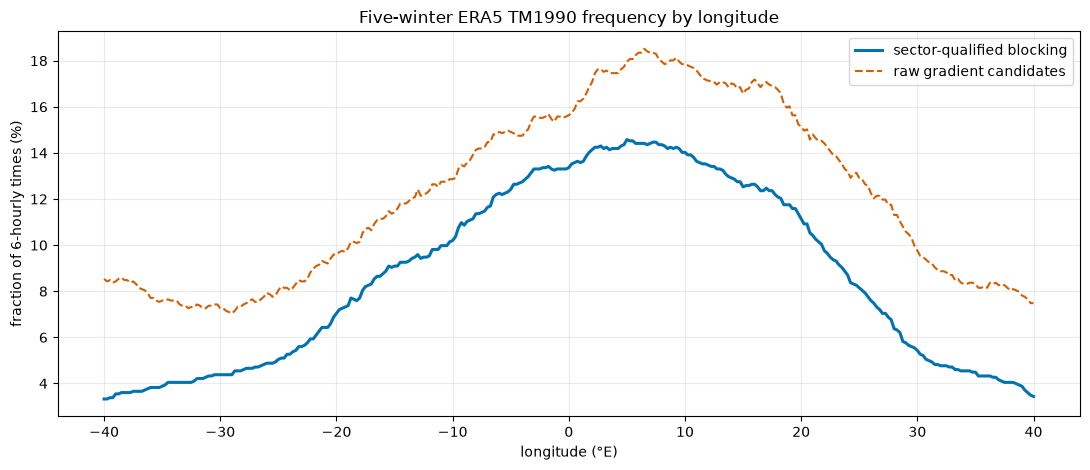

In [4]:
# Combine the five winters into a longitude-frequency benchmark.
blocking_frequency = xr.concat(
    [results[label].blocking for label in results],
    dim="time_z500",
).mean("time_z500")
candidate_frequency = xr.concat(
    [results[label].candidate for label in results],
    dim="time_z500",
).mean("time_z500")
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(
    blocking_frequency.lon,
    100 * blocking_frequency,
    label="sector-qualified blocking",
    color="#0072B2",
    linewidth=2.2,
)
ax.plot(
    candidate_frequency.lon,
    100 * candidate_frequency,
    label="raw gradient candidates",
    color="#D55E00",
    linestyle="--",
)
ax.set(
    xlabel="longitude (°E)",
    ylabel="fraction of 6-hourly times (%)",
    title="Five-winter ERA5 TM1990 frequency by longitude",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

*Figure — pooled longitude frequency across five complete winters. Source:
ERA5/ARCO Z500-only local caches; analysis: the same TM1990 detector used in
the teaching notebook. The dashed curve shows where the local gradient shape
passes. The solid curve shows where it also forms a 20° continuous sector.
The expected scientific use is a broad, interpretable longitude structure,
not a single sharp spike. This is still a pilot benchmark and should not be
reported as the final climatological frequency.*


winter,candidate_percent,sector_percent
str,f64,f64
"""2020-21""",9.459155,5.126341
"""2021-22""",11.768778,8.599862
"""2022-23""",16.884735,14.095708
"""2023-24""",7.283215,4.882578
"""2024-25""",15.681031,10.876601


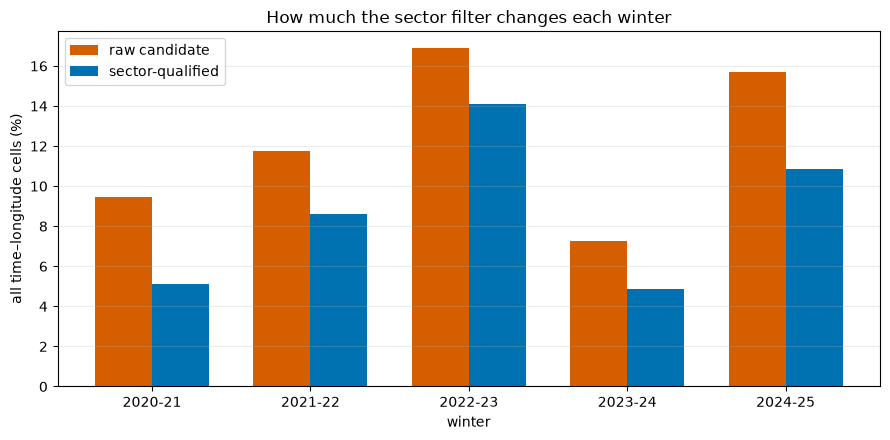

In [5]:
# Compare the candidate and sector-qualified frequencies by winter.
frequency_rows = []
for label, result in results.items():
    frequency_rows.append(
        {
            "winter": label,
            "candidate_percent": 100 * float(result.candidate.mean()),
            "sector_percent": 100 * float(result.blocking.mean()),
        }
    )
frequency_by_winter = pl.DataFrame(frequency_rows)
display(frequency_by_winter)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(frequency_by_winter))
width = 0.36
ax.bar(
    x - width / 2,
    frequency_by_winter["candidate_percent"],
    width,
    label="raw candidate",
    color="#D55E00",
)
ax.bar(
    x + width / 2,
    frequency_by_winter["sector_percent"],
    width,
    label="sector-qualified",
    color="#0072B2",
)
ax.set(
    xticks=x,
    xticklabels=frequency_by_winter["winter"],
    xlabel="winter",
    ylabel="all time–longitude cells (%)",
    title="How much the sector filter changes each winter",
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

*Figure — winter-to-winter stability check. The two bars separate the local
gradient test from the wider-sector requirement. Large differences between
winters are not automatically climate signals here; they may reflect natural
variability, the short five-winter sample, or detector sensitivity. This plot
is primarily a quality-control view before model comparison.*


In [6]:
# Report the benchmark's most frequent longitudes and the correct interpretation.
top_indices = np.argsort(blocking_frequency.values)[-5:][::-1]
top_longitudes = [
    {
        "longitude_deg_e": float(blocking_frequency.lon.values[index]),
        "frequency_percent": 100 * float(blocking_frequency.values[index]),
    }
    for index in top_indices
]
display(pl.DataFrame(top_longitudes))

longitude_deg_e,frequency_percent
f64,f64
5.0,14.578714
5.25,14.523282
5.5,14.523282
7.25,14.467849
7.5,14.467849


## What this benchmark can tell us

- If the inventory is complete and the frequency curves are smooth and
  interpretable, the TM1990 implementation is ready for a historical model
  comparison.
- The difference between the dashed and solid curves shows the practical
  effect of requiring a physically extended longitude sector.
- The winter comparison shows whether one short sample dominates the pooled
  result.

## What it cannot tell us yet

Five winters are not a final climatology and cannot establish a robust trend.
The detector has not yet been compared with an independent published
longitude-frequency benchmark, and it does not identify named events or prove
that blocking causes wind droughts or generation stress.

## Recommended next step

First inspect this notebook and confirm that the data checks, frequencies,
and explanations are understandable. Then add the Dunkelflaute threshold
sweep and overlap analysis on the ERA5/SMARD historical benchmark. EERIE
should follow only after these historical diagnostics are stable.
